# S1 Backtest — percentage stop-loss bake-off (IS)

Set **`N_STAR`**, **`TIMING_STAR`**, **`WEIGHT_STAR`**, and (if `inv_vol`) **`INV_VOL_WINDOW_STAR`** by hand from notebooks 01–03.
On **research IS only**, grid fixed **percentage** stop levels (+ no-stop baseline).

### Per-name percentage stops

- Long stop = ``O_entry * (1 - p/100)``; short = ``O_entry * (1 + p/100)``.
- Daily high/low path; gap-aware fill; liquidate that name **once** (no re-entry).
- Active over the full hold, including the weekend / Mon open gap.
- Same path engine as notebook 05 ATR stops; only the stop *distance* differs.

### Costs (Alpaca-representative)

| Event | One-way |
|---|---|
| Monday open entry / roll | **15.5 bps** (open) |
| Early stop liquidation | **10.5 bps** (close / regular session) |
| Friday scheduled flatten | **10.5 bps** (close) |
| Names already stopped are zeroed so Monday does **not** double-charge their exit |

Pick **`STOP_STAR`** by **IS net Sharpe**. Copy into `08_oos_tearsheet`. No CSV writes.


## 0. Imports & Config


In [6]:
import os
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from backtest.s1_equities.costs import DEFAULT_COSTS, cost_summary
from backtest.s1_equities.portfolio import (
    WEIGHT_EQUAL,
    WEIGHT_INV_VOL,
    WEIGHT_RANK,
    WEIGHT_SCORE,
)
from backtest.s1_equities.report import plot_equity_overlay
from backtest.s1_equities.runner import run_backtest, summarize_periods
from backtest.s1_equities.signals import (
    TIMING_MON_OPEN_FRI_CLOSE,
    TIMING_MON_OPEN_MON_OPEN,
    default_backtest_paths,
    is_mask_from_preds,
    load_ohlc_panels,
    load_predictions,
    prediction_path_for_timing,
    score_matrix,
)
from backtest.s1_equities.stops import STOP_NONE, STOP_PCT, StopConfig
from data.processing.feature_implementation.realized_vol import DEFAULT_OPEN_VOL_WINDOW

PATHS = default_backtest_paths(ROOT)

# --- Set from notebooks 01 / 02 / 03 ---
N_STAR = 15
TIMING_STAR = TIMING_MON_OPEN_MON_OPEN  # or TIMING_MON_OPEN_FRI_CLOSE
WEIGHT_STAR = WEIGHT_INV_VOL  # or WEIGHT_EQUAL / WEIGHT_SCORE / WEIGHT_RANK
# From notebook 03 section 5 when WEIGHT_STAR is inv_vol (ignored otherwise)
INV_VOL_WINDOW_STAR = 42

PCT_LEVELS = [5, 6, 8, 10, 15, 20]
PRED_PATH = prediction_path_for_timing(PATHS, TIMING_STAR)

print(f"N_STAR={N_STAR}  TIMING_STAR={TIMING_STAR}  WEIGHT_STAR={WEIGHT_STAR}")
print(f"INV_VOL_WINDOW_STAR={INV_VOL_WINDOW_STAR} (used when WEIGHT_STAR=inv_vol)")
print(f"predictions={PRED_PATH}")
print(f"PCT_LEVELS={PCT_LEVELS}")
display(pd.Series(cost_summary(DEFAULT_COSTS), name="bps").to_frame())


N_STAR=15  TIMING_STAR=mon_open_mon_open  WEIGHT_STAR=inv_vol
INV_VOL_WINDOW_STAR=42 (used when WEIGHT_STAR=inv_vol)
predictions=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_linear_slim_ffill_is_predictions.parquet
PCT_LEVELS=[5, 6, 8, 10, 15, 20]


,bps
commission_bps,0.0
regulatory_bps,0.5
half_spread_bps,5.0
open_slippage_bps,10.0
close_slippage_bps,5.0
short_borrow_bps,0.0
open_one_way_bps,15.5
close_one_way_bps,10.5


## 1. Daily OHLC (explicit)

Stops use **daily** `high` / `low` from the engineered S1 feature panel parquet
(`PATHS["features"]`), loaded via `load_ohlc_panels` (columns
`date, ticker, open, high, low, close` → wide pivots).


In [7]:
feats_path = PATHS["features"]
print(f"features parquet: {feats_path}")
print(f"exists={os.path.isfile(feats_path)}")

preds = load_predictions(PRED_PATH)
scores = score_matrix(preds)
is_mask = is_mask_from_preds(preds)

opens, highs, lows, closes = load_ohlc_panels(
    feats_path, tickers=list(scores.columns)
)
print(
    f"opens={opens.shape} highs={highs.shape} lows={lows.shape} closes={closes.shape}"
)
print(f"IS entry dates={int(is_mask.sum())}")
display(highs.head(3))
display(lows.head(3))


features parquet: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s1_equities\s1_engineered_features.parquet
exists=True
opens=(4165, 68) highs=(4165, 68) lows=(4165, 68) closes=(4165, 68)
IS entry dates=411


ticker,AAPL,ABT,ADBE,AMAT,AMD,AMGN,AMZN,BA,BAX,BBY,...,PM,QCOM,RRC,SBUX,SLB,TGT,TXN,UNH,VZ,WMT
date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,6.421146,18.111994,37.299999,11.207418,9.90,38.849243,6.8305,43.941189,23.380160,23.332521,...,23.056263,31.296249,48.420293,8.605327,45.351634,30.864642,17.329474,24.322957,13.160060,13.013926
2010-01-06,6.453779,18.082116,37.799999,11.061268,9.90,38.728410,6.7740,45.413942,23.110649,23.861503,...,23.046959,31.964361,49.091264,8.852460,45.635081,31.079299,17.127588,24.607752,13.140382,12.899667
2010-01-07,6.443003,18.055566,37.740002,11.076655,9.76,38.527032,6.7365,46.746436,23.142357,23.769507,...,22.781945,32.037125,49.238326,8.712302,46.525928,31.376009,16.951753,24.677031,13.066893,12.813969


ticker,AAPL,ABT,ADBE,AMAT,AMD,AMGN,AMZN,BA,BAX,BBY,...,PM,QCOM,RRC,SBUX,SLB,TGT,TXN,UNH,VZ,WMT
date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,6.357683,17.899535,36.650002,10.792043,9.68,37.969816,6.6570,42.702201,22.845098,22.786293,...,22.433247,30.806727,46.931287,8.450409,44.622772,30.555303,16.860581,23.838037,13.018427,12.775881
2010-01-06,6.383729,17.843100,36.869999,10.799736,9.68,37.775138,6.5905,43.637282,22.872844,23.286527,...,22.670359,31.421920,48.116974,8.443034,45.034442,30.466930,16.736845,24.076651,12.896459,12.752078
2010-01-07,6.308892,17.876306,37.200001,10.845892,9.55,37.929558,6.5825,45.102245,22.880773,23.378523,...,22.451840,31.342536,48.429482,8.579514,45.236913,30.675256,16.645669,24.176716,12.691729,12.716372


## 2. IS stop grid


In [8]:
configs = [StopConfig(mode=STOP_NONE)]
for p in PCT_LEVELS:
    configs.append(StopConfig(mode=STOP_PCT, pct=float(p)))

results = {}
rows = []
for cfg in configs:
    res = run_backtest(
        scores,
        opens,
        closes,
        n=N_STAR,
        timing_mode=TIMING_STAR,
        weight_mode=WEIGHT_STAR,
        inv_vol_window=INV_VOL_WINDOW_STAR,
        costs=DEFAULT_COSTS,
        date_mask=is_mask,
        highs=highs,
        lows=lows,
        stop=cfg,
    )
    label = cfg.label()
    results[label] = res
    sm = summarize_periods(res.period_returns)
    rows.append(
        {
            "stop": label,
            "pct": cfg.pct,
            "sharpe": sm["sharpe"],
            "cagr": sm["cagr"],
            "total_return": sm["total_return"],
            "max_drawdown": sm["max_drawdown"],
            "vol": sm["vol"],
            "win_rate": sm["win_rate"],
            "mean_turnover": float(res.turnover.mean()) if len(res.turnover) else np.nan,
            "n_periods": sm["n_periods"],
            "stop_hit_rate": res.stop_hit_rate,
            "mean_names_stopped": res.mean_names_stopped,
            "mean_early_exit_notional": res.mean_early_exit_notional,
        }
    )
    print(
        f"{label}: sharpe={sm['sharpe']:.3f}  dd={sm['max_drawdown']:.3%}  "
        f"hit={res.stop_hit_rate:.3f}  turn={res.turnover.mean():.3f}"
    )

bake_df = pd.DataFrame(rows).set_index("stop")
display(bake_df.sort_values("sharpe", ascending=False))

best = bake_df["sharpe"].idxmax()
STOP_STAR = str(best)
print(f"Suggested STOP_STAR={STOP_STAR}  (IS net Sharpe={bake_df.loc[STOP_STAR, 'sharpe']:.4f})")
print("Copy this string into STOP_STAR in notebook 08.")


none: sharpe=0.938  dd=-20.990%  hit=0.000  turn=0.169
pct_5: sharpe=-0.082  dd=-29.592%  hit=0.177  turn=0.358
pct_6: sharpe=0.138  dd=-27.711%  hit=0.129  turn=0.302
pct_8: sharpe=0.480  dd=-24.689%  hit=0.073  turn=0.240
pct_10: sharpe=0.656  dd=-23.253%  hit=0.043  turn=0.208
pct_15: sharpe=0.821  dd=-21.553%  hit=0.014  turn=0.180
pct_20: sharpe=0.882  dd=-20.756%  hit=0.005  turn=0.173


,pct,sharpe,cagr,total_return,max_drawdown,vol,win_rate,mean_turnover,n_periods,stop_hit_rate,mean_names_stopped,mean_early_exit_notional
stop,,,,,,,,,,,,
none,NaN,0.938172,0.073793,0.753056,-0.209901,0.079294,0.602439,0.169383,410,0.000000,0.000000,0.000000
pct_20,20.0,0.881920,0.068098,0.681082,-0.207560,0.078220,0.600000,0.172833,410,0.005447,0.163415,0.003036
pct_15,15.0,0.821201,0.063787,0.628315,-0.215534,0.079163,0.600000,0.180134,410,0.014065,0.421951,0.008834
pct_10,10.0,0.656260,0.050160,0.470925,-0.232533,0.079425,0.590244,0.207634,410,0.042520,1.275610,0.030243
pct_8,8.0,0.480212,0.035948,0.321098,-0.246888,0.080293,0.580488,0.239928,410,0.073415,2.202439,0.054871
pct_6,6.0,0.138114,0.007820,0.063342,-0.277113,0.079109,0.560976,0.301512,410,0.129024,3.870732,0.102395
pct_5,5.0,-0.081903,-0.009464,-0.072230,-0.295919,0.078447,0.541463,0.358017,410,0.176504,5.295122,0.144520


Suggested STOP_STAR=none  (IS net Sharpe=0.9382)
Copy this string into STOP_STAR in notebook 07.


## 3. Sharpe curve & equity overlay


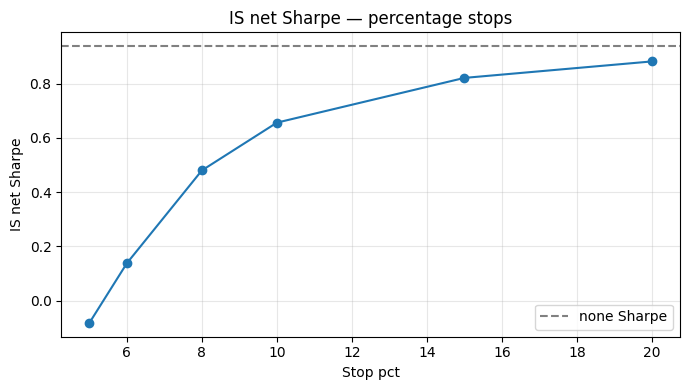

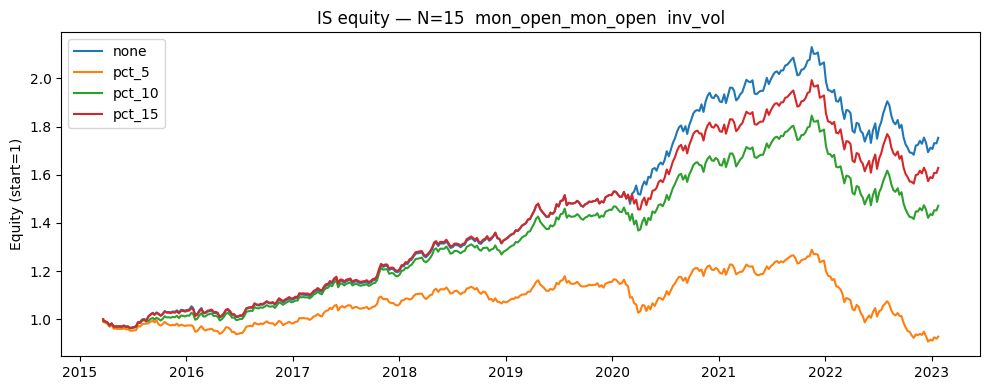

In [9]:
pct_only = bake_df.dropna(subset=["pct"]).sort_values("pct")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(pct_only["pct"], pct_only["sharpe"], marker="o")
if STOP_NONE in bake_df.index and np.isfinite(bake_df.loc[STOP_NONE, "sharpe"]):
    ax.axhline(
        bake_df.loc[STOP_NONE, "sharpe"],
        color="gray",
        linestyle="--",
        label=f"{STOP_NONE} Sharpe",
    )
ax.set_xlabel("Stop pct")
ax.set_ylabel("IS net Sharpe")
ax.set_title("IS net Sharpe — percentage stops")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

overlay_keys = [STOP_NONE, STOP_STAR]
for cand in ("pct_5", "pct_10", "pct_15"):
    if cand in results and cand not in overlay_keys:
        overlay_keys.append(cand)
fig = plot_equity_overlay(
    {k: results[k].equity for k in overlay_keys if k in results},
    title=f"IS equity — N={N_STAR}  {TIMING_STAR}  {WEIGHT_STAR}",
)
plt.show()


## 4. Suggested STOP_STAR


In [10]:
print(
    f"Suggested STOP_STAR={STOP_STAR} — set STOP_STAR={STOP_STAR!r} in 08_oos_tearsheet"
)
display(bake_df.loc[[STOP_STAR]].T)


Suggested STOP_STAR=none — set STOP_STAR='none' in 07_oos_tearsheet


stop,none
pct,NaN
sharpe,0.938172
cagr,0.073793
total_return,0.753056
max_drawdown,-0.209901
vol,0.079294
win_rate,0.602439
mean_turnover,0.169383
n_periods,410.000000
stop_hit_rate,0.000000
